In [1]:
!pip install ultralytics

Detected objects: 17
Unique class IDs: [0 1]
Class names: ['goalkeeper' 'player']
Field model predicted keypoints: 32
Template keypoints: 32
Using keypoints for homography: [30, 15, 9, 16, 10, 14, 13, 0, 11, 8, 31, 19, 18, 1, 20, 6]
Keypoint names: ['14', '17', '10', '18', '11', '16', '15', '1', '12', '9', '19', '22', '21', '2', '23', '7']
Keypoint confidences: [0.75, 0.26100000739097595, 0.2199999988079071, 0.1459999978542328, 0.14100000262260437, 0.09399999678134918, 0.05299999937415123, 0.0430000014603138, 0.04100000113248825, 0.01899999938905239, 0.014999999664723873, 0.014999999664723873, 0.013000000268220901, 0.012000000104308128, 0.010999999940395355, 0.010999999940395355]
Homography inliers: 8 / 16
Player frame points: (17, 2)
Projected player points: (17, 2)
Projected inside pitch: (4, 2)
First projected points:
[[      52.92      112.82]
 [      43.93       70.15]
 [      92.17      152.57]
 [     100.72      158.24]
 [     199.47      193.18]
 [      72.67      131.12]
 [   

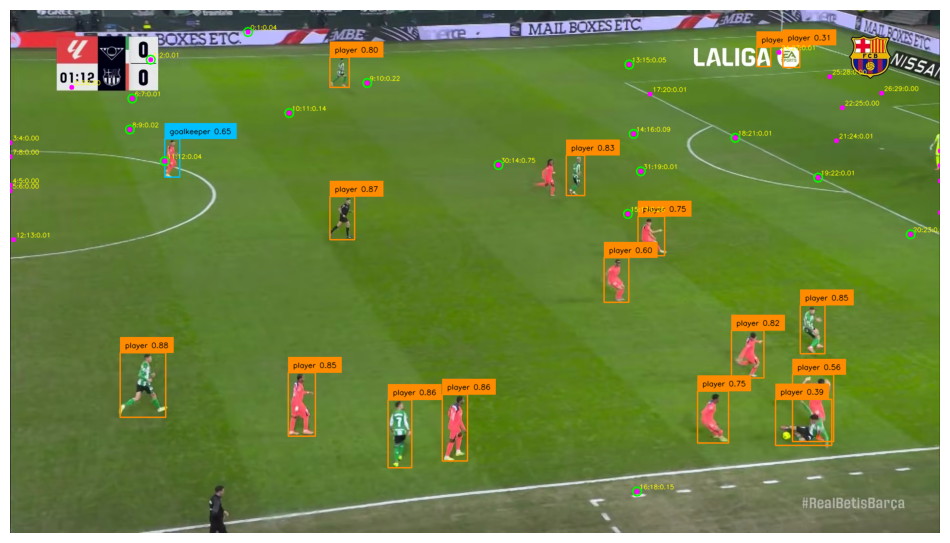

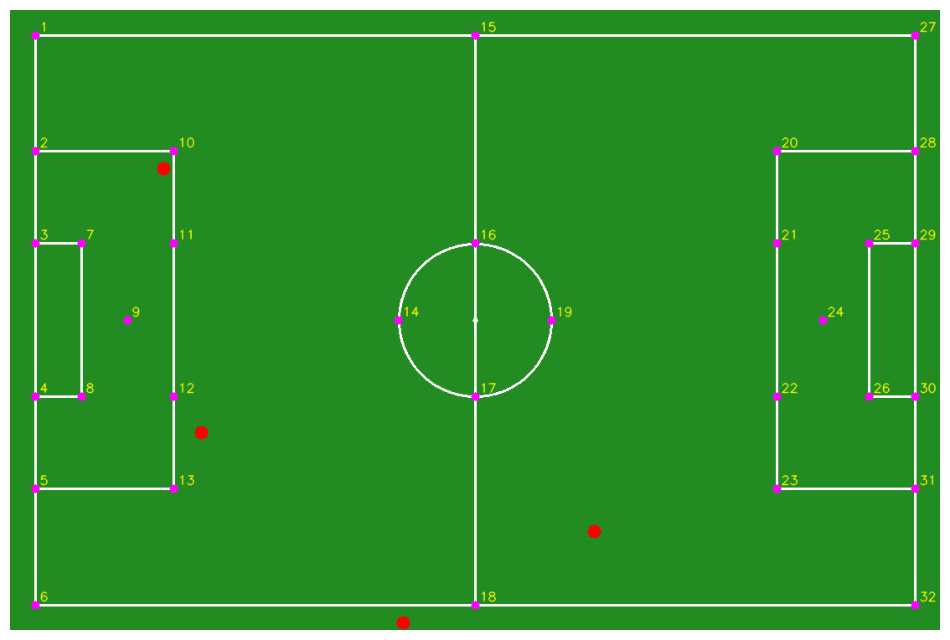

In [6]:
# %%
import cv2
import numpy as np
import supervision as sv
from ultralytics import YOLO

# =========================================================
# PATHS
# =========================================================
SOURCE_VIDEO_PATH = "data/test_data/FULL MATCH ｜ BETIS 3 vs 5 FC BARCELONA ｜ LALIGA 2025⧸26 MD15 🔵🔴 [93LPZJkCW2w].webm"
PLAYER_MODEL_PATH = "models/obb_model/best.pt"
FIELD_MODEL_PATH = "models/keypoint_model/best.pt"

# =========================================================
# MODELS
# =========================================================
PLAYER_DETECTION_MODEL = YOLO(PLAYER_MODEL_PATH)
FIELD_DETECTION_MODEL = YOLO(FIELD_MODEL_PATH)

# =========================================================
# PITCH GEOMETRY
# Standard football pitch in meters
# =========================================================
PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0

# IMPORTANT:
# Your field model predicts 32 keypoints.
# This order matches the common Roboflow/Sports 32-keypoint pitch model:
# 1-13, 15-18, 20-32, then 14 and 19 at the end.
KEYPOINT_ORDER = [
    "1", "2", "3", "4", "5", "6",
    "7", "8", "9", "10", "11", "12", "13",
    "15", "16", "17", "18",
    "20", "21", "22", "23", "24", "25", "26",
    "27", "28", "29", "30", "31", "32",
    "14", "19",
]

# Football pitch markings in meters
PENALTY_AREA_DEPTH = 16.5
PENALTY_AREA_WIDTH = 40.32

GOAL_AREA_DEPTH = 5.5
GOAL_AREA_WIDTH = 18.32

PENALTY_SPOT_DISTANCE = 11.0

CENTER_X = PITCH_LENGTH / 2.0
CENTER_Y = PITCH_WIDTH / 2.0
CENTER_CIRCLE_RADIUS = 9.15

PENALTY_Y_TOP = (PITCH_WIDTH - PENALTY_AREA_WIDTH) / 2.0
PENALTY_Y_BOTTOM = (PITCH_WIDTH + PENALTY_AREA_WIDTH) / 2.0

GOAL_AREA_Y_TOP = (PITCH_WIDTH - GOAL_AREA_WIDTH) / 2.0
GOAL_AREA_Y_BOTTOM = (PITCH_WIDTH + GOAL_AREA_WIDTH) / 2.0

LEFT_PENALTY_X = PENALTY_AREA_DEPTH
RIGHT_PENALTY_X = PITCH_LENGTH - PENALTY_AREA_DEPTH

LEFT_GOAL_AREA_X = GOAL_AREA_DEPTH
RIGHT_GOAL_AREA_X = PITCH_LENGTH - GOAL_AREA_DEPTH

LEFT_PENALTY_SPOT_X = PENALTY_SPOT_DISTANCE
RIGHT_PENALTY_SPOT_X = PITCH_LENGTH - PENALTY_SPOT_DISTANCE

# Canonical pitch template keyed by the labels in your diagram
PITCH_TEMPLATE = {
    # Left goal line / touchline side
    "1": (0.0, 0.0),
    "2": (0.0, PENALTY_Y_TOP),
    "3": (0.0, GOAL_AREA_Y_TOP),
    "4": (0.0, GOAL_AREA_Y_BOTTOM),
    "5": (0.0, PENALTY_Y_BOTTOM),
    "6": (0.0, PITCH_WIDTH),

    # Left goal area / penalty area / spot
    "7": (LEFT_GOAL_AREA_X, GOAL_AREA_Y_TOP),
    "8": (LEFT_GOAL_AREA_X, GOAL_AREA_Y_BOTTOM),
    "9": (LEFT_PENALTY_SPOT_X, CENTER_Y),
    "10": (LEFT_PENALTY_X, PENALTY_Y_TOP),
    "11": (LEFT_PENALTY_X, GOAL_AREA_Y_TOP),
    "12": (LEFT_PENALTY_X, GOAL_AREA_Y_BOTTOM),
    "13": (LEFT_PENALTY_X, PENALTY_Y_BOTTOM),

    # Center circle / center line
    "14": (CENTER_X - CENTER_CIRCLE_RADIUS, CENTER_Y),
    "15": (CENTER_X, 0.0),
    "16": (CENTER_X, CENTER_Y - CENTER_CIRCLE_RADIUS),
    "17": (CENTER_X, CENTER_Y + CENTER_CIRCLE_RADIUS),
    "18": (CENTER_X, PITCH_WIDTH),
    "19": (CENTER_X + CENTER_CIRCLE_RADIUS, CENTER_Y),

    # Right penalty area / spot / goal area
    "20": (RIGHT_PENALTY_X, PENALTY_Y_TOP),
    "21": (RIGHT_PENALTY_X, GOAL_AREA_Y_TOP),
    "22": (RIGHT_PENALTY_X, GOAL_AREA_Y_BOTTOM),
    "23": (RIGHT_PENALTY_X, PENALTY_Y_BOTTOM),
    "24": (RIGHT_PENALTY_SPOT_X, CENTER_Y),
    "25": (RIGHT_GOAL_AREA_X, GOAL_AREA_Y_TOP),
    "26": (RIGHT_GOAL_AREA_X, GOAL_AREA_Y_BOTTOM),

    # Right goal line / touchline side
    "27": (PITCH_LENGTH, 0.0),
    "28": (PITCH_LENGTH, PENALTY_Y_TOP),
    "29": (PITCH_LENGTH, GOAL_AREA_Y_TOP),
    "30": (PITCH_LENGTH, GOAL_AREA_Y_BOTTOM),
    "31": (PITCH_LENGTH, PENALTY_Y_BOTTOM),
    "32": (PITCH_LENGTH, PITCH_WIDTH),
}

PITCH_KEYPOINTS = np.array(
    [PITCH_TEMPLATE[name] for name in KEYPOINT_ORDER],
    dtype=np.float32
)

# Lines for drawing the 2D pitch
PITCH_EDGES = [
    # Left goal line
    ("1", "2"),
    ("2", "3"),
    ("3", "4"),
    ("4", "5"),
    ("5", "6"),

    # Top and bottom touchlines
    ("1", "15"),
    ("15", "27"),
    ("6", "18"),
    ("18", "32"),

    # Right goal line
    ("27", "28"),
    ("28", "29"),
    ("29", "30"),
    ("30", "31"),
    ("31", "32"),

    # Left penalty box
    ("2", "10"),
    ("10", "11"),
    ("11", "12"),
    ("12", "13"),
    ("13", "5"),

    # Left goal area
    ("3", "7"),
    ("7", "8"),
    ("8", "4"),

    # Center line
    ("15", "16"),
    ("16", "17"),
    ("17", "18"),

    # Right penalty box
    ("28", "20"),
    ("20", "21"),
    ("21", "22"),
    ("22", "23"),
    ("23", "31"),

    # Right goal area
    ("29", "25"),
    ("25", "26"),
    ("26", "30"),
]

# =========================================================
# DRAWING SETTINGS
# =========================================================
DRAW_SCALE = 10
PITCH_BORDER = 30

box_annotator = sv.BoxAnnotator(
    color=sv.ColorPalette.from_hex(["#FF8C00", "#00BFFF", "#FF1493", "#FFD700"]),
    thickness=2
)

label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(["#FF8C00", "#00BFFF", "#FF1493", "#FFD700"]),
    text_color=sv.Color.from_hex("#000000")
)

vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex("#FF1493"),
    radius=6
)

# =========================================================
# HELPERS
# =========================================================
def ultralytics_result_to_detections(result) -> sv.Detections:
    """
    Convert Ultralytics detection result to supervision.Detections.
    Supports standard boxes and OBB fallback.
    """
    # Standard boxes
    if hasattr(result, "boxes") and result.boxes is not None and len(result.boxes) > 0:
        xyxy = result.boxes.xyxy.cpu().numpy()
        confidence = result.boxes.conf.cpu().numpy() if result.boxes.conf is not None else np.ones(len(xyxy))
        class_id = result.boxes.cls.cpu().numpy().astype(int) if result.boxes.cls is not None else np.zeros(len(xyxy), dtype=int)

        data = {}
        if hasattr(result, "names") and result.names is not None:
            data["class_name"] = np.array([result.names[int(cid)] for cid in class_id])

        return sv.Detections(
            xyxy=xyxy,
            confidence=confidence,
            class_id=class_id,
            data=data
        )

    # OBB fallback
    if hasattr(result, "obb") and result.obb is not None and len(result.obb) > 0:
        if hasattr(result.obb, "xyxy") and result.obb.xyxy is not None:
            xyxy = result.obb.xyxy.cpu().numpy()
            confidence = result.obb.conf.cpu().numpy() if result.obb.conf is not None else np.ones(len(xyxy))
            class_id = result.obb.cls.cpu().numpy().astype(int) if result.obb.cls is not None else np.zeros(len(xyxy), dtype=int)

            data = {}
            if hasattr(result, "names") and result.names is not None:
                data["class_name"] = np.array([result.names[int(cid)] for cid in class_id])

            return sv.Detections(
                xyxy=xyxy,
                confidence=confidence,
                class_id=class_id,
                data=data
            )

    return sv.Detections.empty()


def ultralytics_keypoints_to_numpy(result):
    """
    Returns:
        xy:   (N, 2)
        conf: (N,)
    """
    if result.keypoints is None:
        raise ValueError("No keypoints found in field model result.")

    xy = result.keypoints.xy.cpu().numpy()
    if xy.ndim != 3 or xy.shape[0] == 0:
        raise ValueError(f"Unexpected keypoint shape: {xy.shape}")

    xy = xy[0].astype(np.float32)

    if hasattr(result.keypoints, "conf") and result.keypoints.conf is not None:
        conf = result.keypoints.conf.cpu().numpy()[0].astype(np.float32)
    else:
        conf = np.ones((xy.shape[0],), dtype=np.float32)

    return xy, conf


def auto_filter_player_like_detections(detections: sv.Detections) -> sv.Detections:
    """
    Try to keep player-like detections only.
    If class names are unavailable, returns all detections.
    """
    if len(detections) == 0:
        return detections

    if "class_name" not in detections.data:
        return detections

    class_names = np.array([str(x).lower() for x in detections.data["class_name"]])

    keep = np.array([
        ("player" in name) or
        ("goalkeeper" in name) or
        ("keeper" in name) or
        ("referee" in name) or
        ("person" in name) or
        ("ball" in name)
        for name in class_names
    ])

    # If nothing matched, fallback to all detections
    if keep.sum() == 0:
        return detections

    return detections[keep]


def get_bottom_center_points(detections: sv.Detections) -> np.ndarray:
    """
    Use bottom-center of each bbox as the player's ground contact point.
    """
    if len(detections) == 0:
        return np.empty((0, 2), dtype=np.float32)

    xyxy = detections.xyxy.astype(np.float32)
    x = (xyxy[:, 0] + xyxy[:, 2]) / 2.0
    y = xyxy[:, 3]
    return np.stack([x, y], axis=1).astype(np.float32)


def select_reference_keypoints(frame_kps, frame_kps_conf, pitch_kps, min_points=4, max_points=16, min_conf=0.80):
    """
    Select robust keypoints for homography.
    First uses all visible points above min_conf.
    If too few remain, falls back to top-K visible points.
    """
    if len(frame_kps) != len(pitch_kps):
        raise ValueError(
            f"Mismatch: frame keypoints = {len(frame_kps)}, pitch keypoints = {len(pitch_kps)}"
        )

    valid = (
        np.isfinite(frame_kps).all(axis=1) &
        np.isfinite(frame_kps_conf) &
        (frame_kps[:, 0] > 1) &
        (frame_kps[:, 1] > 1)
    )

    frame_kps_valid = frame_kps[valid]
    frame_kps_conf_valid = frame_kps_conf[valid]
    pitch_kps_valid = pitch_kps[valid]
    original_indices_valid = np.where(valid)[0]

    mask = frame_kps_conf_valid >= min_conf
    selected_frame = frame_kps_valid[mask]
    selected_pitch = pitch_kps_valid[mask]
    selected_conf = frame_kps_conf_valid[mask]
    selected_indices = original_indices_valid[mask]

    if len(selected_frame) < min_points:
        order = np.argsort(frame_kps_conf_valid)[::-1]
        keep = order[:min(max_points, len(order))]

        selected_frame = frame_kps_valid[keep]
        selected_pitch = pitch_kps_valid[keep]
        selected_conf = frame_kps_conf_valid[keep]
        selected_indices = original_indices_valid[keep]

    if len(selected_frame) < min_points:
        raise ValueError(
            f"Need at least {min_points} visible keypoints for homography, found {len(selected_frame)}."
        )

    return selected_frame, selected_pitch, selected_conf, selected_indices


def compute_homography(frame_points: np.ndarray, pitch_points: np.ndarray):
    H, mask = cv2.findHomography(
        frame_points,
        pitch_points,
        method=cv2.RANSAC,
        ransacReprojThreshold=3.0
    )

    if H is None:
        raise ValueError("cv2.findHomography failed.")

    return H, mask


def apply_homography(points: np.ndarray, H: np.ndarray) -> np.ndarray:
    if len(points) == 0:
        return np.empty((0, 2), dtype=np.float32)

    pts = points.reshape(-1, 1, 2).astype(np.float32)
    transformed = cv2.perspectiveTransform(pts, H)
    return transformed.reshape(-1, 2)


def keep_points_inside_pitch(points_pitch: np.ndarray, margin=5.0):
    if len(points_pitch) == 0:
        return np.empty((0, 2), dtype=np.float32), np.array([], dtype=bool)

    mask = (
        (points_pitch[:, 0] >= -margin) &
        (points_pitch[:, 0] <= PITCH_LENGTH + margin) &
        (points_pitch[:, 1] >= -margin) &
        (points_pitch[:, 1] <= PITCH_WIDTH + margin)
    )

    return points_pitch[mask], mask


def pitch_to_image_coords(points_pitch: np.ndarray) -> np.ndarray:
    pts = points_pitch.copy()
    pts[:, 0] = pts[:, 0] * DRAW_SCALE + PITCH_BORDER
    pts[:, 1] = pts[:, 1] * DRAW_SCALE + PITCH_BORDER
    return pts.astype(int)


def draw_2d_pitch():
    """
    Draw the pitch using the 32-keypoint pitch template geometry.
    """
    width_px = int(PITCH_LENGTH * DRAW_SCALE + 2 * PITCH_BORDER)
    height_px = int(PITCH_WIDTH * DRAW_SCALE + 2 * PITCH_BORDER)

    pitch = np.zeros((height_px, width_px, 3), dtype=np.uint8)
    pitch[:] = (34, 139, 34)

    pts = {
        name: tuple(pitch_to_image_coords(np.array([xy], dtype=np.float32))[0])
        for name, xy in PITCH_TEMPLATE.items()
    }

    # Main pitch markings
    for a, b in PITCH_EDGES:
        cv2.line(pitch, pts[a], pts[b], (255, 255, 255), 2)

    # Center circle
    center_px = tuple(
        pitch_to_image_coords(
            np.array([[CENTER_X, CENTER_Y]], dtype=np.float32)
        )[0]
    )
    radius_px = int(CENTER_CIRCLE_RADIUS * DRAW_SCALE)
    cv2.circle(pitch, center_px, radius_px, (255, 255, 255), 2)

    # Penalty spots and center spot
    for point_name in ["9", "24"]:
        cv2.circle(pitch, pts[point_name], 3, (255, 255, 255), -1)

    cv2.circle(pitch, center_px, 3, (255, 255, 255), -1)

    return pitch


def draw_keypoint_debug(frame: np.ndarray, frame_kps: np.ndarray, frame_kps_conf: np.ndarray):
    out = frame.copy()

    for i, ((x, y), conf, name) in enumerate(zip(frame_kps.astype(int), frame_kps_conf, KEYPOINT_ORDER)):
        cv2.circle(out, (x, y), 5, (255, 0, 255), -1)
        cv2.putText(
            out,
            f"{i}:{name}:{conf:.2f}",
            (x + 5, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.42,
            (0, 255, 255),
            1,
            cv2.LINE_AA
        )

    return out


# =========================================================
# READ A FRAME
# Change start frame if needed
# =========================================================
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=200)
frame = next(frame_generator)

# =========================================================
# PLAYER DETECTION
# =========================================================
player_result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.25, verbose=False)[0]
detections = ultralytics_result_to_detections(player_result)
detections = auto_filter_player_like_detections(detections)

print("Detected objects:", len(detections))

if len(detections) > 0:
    print("Unique class IDs:", np.unique(detections.class_id))

    if "class_name" in detections.data:
        print("Class names:", np.unique(detections.data["class_name"]))

# =========================================================
# FIELD KEYPOINT DETECTION
# =========================================================
field_result = FIELD_DETECTION_MODEL.predict(frame, conf=0.25, verbose=False)[0]
frame_kps, frame_kps_conf = ultralytics_keypoints_to_numpy(field_result)

print("Field model predicted keypoints:", len(frame_kps))
print("Template keypoints:", len(PITCH_KEYPOINTS))

if len(frame_kps) != len(PITCH_KEYPOINTS):
    raise ValueError(
        f"Field model predicts {len(frame_kps)} keypoints, but template has {len(PITCH_KEYPOINTS)}. "
        "Your model should use the 32-keypoint order in KEYPOINT_ORDER."
    )

frame_reference_points, pitch_reference_points, selected_conf, selected_indices = select_reference_keypoints(
    frame_kps=frame_kps,
    frame_kps_conf=frame_kps_conf,
    pitch_kps=PITCH_KEYPOINTS,
    min_points=4,
    max_points=16,
)

print("Using keypoints for homography:", selected_indices.tolist())
print("Keypoint names:", [KEYPOINT_ORDER[i] for i in selected_indices])
print("Keypoint confidences:", np.round(selected_conf, 3).tolist())

# =========================================================
# HOMOGRAPHY: frame -> pitch
# =========================================================
H, inlier_mask = compute_homography(frame_reference_points, pitch_reference_points)

if inlier_mask is not None:
    print("Homography inliers:", int(inlier_mask.sum()), "/", len(inlier_mask))

# =========================================================
# PROJECT PLAYERS
# =========================================================
player_points_frame = get_bottom_center_points(detections)
player_points_pitch_all = apply_homography(player_points_frame, H)
player_points_pitch, valid_mask = keep_points_inside_pitch(player_points_pitch_all, margin=5.0)

print("Player frame points:", player_points_frame.shape)
print("Projected player points:", player_points_pitch_all.shape)
print("Projected inside pitch:", player_points_pitch.shape)

if len(player_points_pitch_all) > 0:
    print("First projected points:")
    print(np.round(player_points_pitch_all[:10], 2))

# =========================================================
# DRAW ANNOTATED VIDEO FRAME
# =========================================================
annotated_frame = frame.copy()

if len(detections) > 0:
    labels = None

    if "class_name" in detections.data:
        labels = [
            f"{class_name} {confidence:.2f}"
            for class_name, confidence in zip(detections.data["class_name"], detections.confidence)
        ]

    annotated_frame = box_annotator.annotate(
        scene=annotated_frame,
        detections=detections
    )

    if labels is not None:
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections,
            labels=labels
        )

annotated_frame = draw_keypoint_debug(annotated_frame, frame_kps, frame_kps_conf)

for x, y in frame_reference_points.astype(int):
    cv2.circle(annotated_frame, (x, y), 9, (0, 255, 0), 2)

sv.plot_image(annotated_frame)

# =========================================================
# DRAW 2D PITCH PROJECTION
# =========================================================
pitch_img = draw_2d_pitch()

# Draw template keypoints with names
pitch_template_img = pitch_to_image_coords(PITCH_KEYPOINTS.copy())

for name, (x, y) in zip(KEYPOINT_ORDER, pitch_template_img):
    cv2.circle(pitch_img, (x, y), 5, (255, 0, 255), -1)
    cv2.putText(
        pitch_img,
        name,
        (x + 5, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 255),
        1,
        cv2.LINE_AA
    )

# Draw all projected players faintly
for x, y in player_points_pitch_all:
    xi = int(x * DRAW_SCALE + PITCH_BORDER)
    yi = int(y * DRAW_SCALE + PITCH_BORDER)

    if -50 <= xi < pitch_img.shape[1] + 50 and -50 <= yi < pitch_img.shape[0] + 50:
        cv2.circle(pitch_img, (xi, yi), 4, (0, 165, 255), -1)

# Draw valid projected players strongly
for x, y in player_points_pitch:
    xi = int(x * DRAW_SCALE + PITCH_BORDER)
    yi = int(y * DRAW_SCALE + PITCH_BORDER)

    if 0 <= xi < pitch_img.shape[1] and 0 <= yi < pitch_img.shape[0]:
        cv2.circle(pitch_img, (xi, yi), 8, (0, 0, 255), -1)

sv.plot_image(pitch_img)

In [2]:
PLAYER_DETECTION_MODEL.names

{0: 'player', 1: 'goalkeeper', 2: 'referee', 3: 'ball', 4: 'staff', 5: 'other'}